# 2. Every count reconciles and nothing was rejected: is the pass finished?

**Week 1, Friday. The lab debrief, chapter 2 of 3.** Chapter 1 put the room's hurried headline
beside Finance's books, on an invented export: the hurried pass sent Q2 up 21.2 percent, a count
check moved it to -17.5 percent with every order landing, and only the rupee check reached the
books' -35.0. This chapter asks what else a pass can lose when every count lands, sizes four ways
to handle a value that will not convert, and follows the same silence one step later, into a
segment filter.

**Who needs the answer.** Anand Iyer's analyst audits every note before it reaches Meera Raghavan,
and asks for the rupees before the rows. A base quarter short by one large order can halve the fall
the note reports: nobody argues with the direction, so nobody acts at the right scale, and when
Finance finds the missing order every other number in the note is doubted with it.

**The questions on the way.**

1. What does a pass that sets unreadable values to zero report?
2. What do the rupees say when every count lands?
3. Which of four answers fits a value that will not convert?
4. What does reading the value change in the note?
5. Can a segment filter drop a row without a word, as the zero did?
6. Can the file alone, with no control total, find the gap?

**The metric at stake.** Q1 booked revenue, the base every Q1 to Q2 rate is measured from.

**Who else faces this.** JPMorgan Chase's own task force reviewed the losses from the 2012 "London
Whale" trades, as the high-risk trading in the Synthetic Credit Portfolio of the bank's Chief
Investment Office became known (FCA, 19 September 2013). It found that a risk model run through
spreadsheets "divided by their sum instead of their average", which "likely had the effect of
muting volatility by a factor of two and of lowering the VaR" (the task force report of January
2013, as quoted by The Baseline Scenario, 9 February 2013). Muting volatility means the model showed
prices swinging half as much as they did, and VaR, value at risk, is a bank's estimate of how much a
portfolio could lose on a bad day, so the error made the book look safer than it was. The trading
losses came to $6.2 billion (FCA, 19 September 2013). Nothing crashed: the sheet produced a plausible
number every day.

**Before you read on.** This notebook runs on an invented export built for the debrief: 175 rows
over two quarters, with Finance's control totals beside it. Its numbers are labelled invented
wherever they appear, and none of them is Kalpa's or this morning's. After each step, the lines under
**Your turn** run the same step on this morning's lab export: once the lab is over, type them into the
empty cell below them and run the cells in order.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import random
import statistics
from math import comb

QUARTERS = ("Q1", "Q2")
SEGS = ("Retail-Core", "Retail-Plus", "Student", "Business")


def load_export(which):
    """An export and Finance's control totals for it: "invented" for this debrief, "lab" for this morning's file."""
    orders = kit.load_csv(f"C2_W01_D05_{which}_orders_STUDENT.csv")
    book = {c["quarter"]: c for c in kit.load_csv(f"C2_W01_D05_{which}_control_STUDENT.csv")}
    return orders, book


def change(a, b):
    """Percentage change from a to b."""
    return 100 * (b / a - 1)


def ctl(q, book=None):
    """Finance's rupees and orders for a quarter, from the invented export's book unless another is given."""
    book = book or control
    return int(book[q]["amount_rs"]), int(book[q]["orders"])


def read_value(text):
    """The number an amount stored as text holds, read the way a person reads it in the forms this
    week's exports used; None when reading it would take a guess."""
    t = str(text).strip().replace("Rs", "").replace(",", "").replace(" ", "")
    try:
        return round(float(t))
    except ValueError:
        return None


rows, control = load_export("invented")
print(f"The invented export: {len(rows)} rows over two quarters, with Finance's control totals for "
      f"{' and '.join(sorted(control))}. Every number it gives is invented.")


def first_of_each(src):
    """One row per order id, the first to arrive: the identity rule from chapter 1."""
    kept = {}
    for r in src:
        kept.setdefault(r["order_id"], r)
    return list(kept.values())


once = first_of_each(rows)
truth = change(ctl("Q1")[0], ctl("Q2")[0])
print(f"{len(once)} orders after one row per order id; the books say Q1 to Q2 {truth:+.1f}% (invented)")

The invented export: 175 rows over two quarters, with Finance's control totals for Q1 and Q2. Every number it gives is invented.
167 orders after one row per order id; the books say Q1 to Q2 -35.0% (invented)


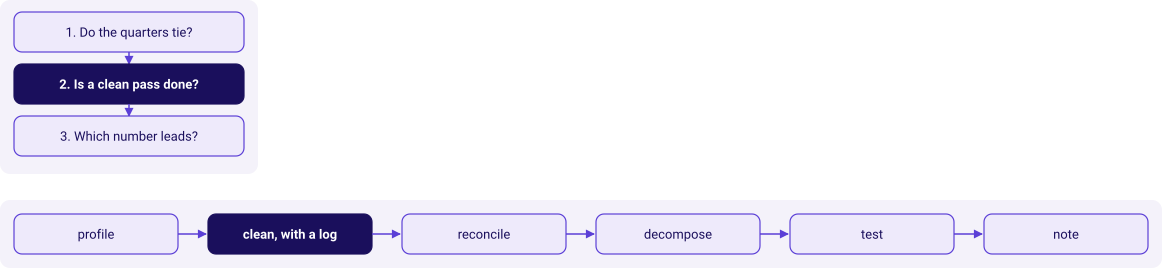

In [2]:
kit.side_by_side(
    kit.ladder(["Do the quarters tie?", "Is a clean pass done?", "Which number leads?"], lit=1, show=False),
    kit.flow(["profile", "clean, with a log", "reconcile", "decompose", "test", "note"], lit=1, show=False),
)

## 1. What does a pass that sets unreadable values to zero report?

The most natural line of Python in the week wraps the conversion in a `try` and sets a failure to
zero, and it runs to the end without an error.

**Predict before you run.** The pass keeps one row per order and sets any value that will not
convert to zero. On the invented export, how many orders does Q1 report against Finance's 83, and
how many rejects?

- a) 82 orders and 1 reject.
- b) 83 orders and 0 rejects.
- c) 83 orders and 1 reject.
- d) 81 orders and 2 rejects.

In [3]:
def to_int_or_zero(v):
    try:
        return int(v)
    except ValueError:
        return 0          # the file now "converts" cleanly


def zeroing_pass(src):
    return {q: [to_int_or_zero(r["amount"]) for r in src if r["quarter"] == q] for q in QUARTERS}


zeroed = zeroing_pass(once)
kit.stats([(len(zeroed["Q1"]), "Q1 orders", f"Finance: {ctl('Q1')[1]}, invented"),
           (0, "rejects reported", "the try swallowed every failure"),
           ("all", "rows kept", "nothing set aside")])
kit.check("the zeroing pass lands on Finance's order counts", all(len(zeroed[q]) == ctl(q)[1] for q in QUARTERS))

**What happened.** The answer is b. Every order count lands and nothing is rejected, which is
exactly what a finished pass looks like.

**Your turn, on this morning's file.** Run the same zeroing pass on the lab export. Type these
lines into the empty cell below and run it; later your-turn cells use `lab` and `lab_once`, so run
this one first:

```python
lab, lab_book = load_export("lab")
lab_once = first_of_each(lab)
lab_zeroed = zeroing_pass(lab_once)
print({q: (len(lab_zeroed[q]), ctl(q, lab_book)[1]) for q in QUARTERS}, "orders against Finance's; 0 rejects")
```

## 2. What do the rupees say when every count lands?

**The plausible wrong answer.** "Q1 on 83 orders, zero rejects, counts reconciled; Q2 fell 17.5
percent." Every word of it can be defended except the number the rate is built on.

**Predict before you run.** Against Finance's rupee totals, what does the zeroing pass show on the
invented export?

- a) Both quarters land to the rupee.
- b) One quarter over, the other landing.
- c) One quarter short, the other landing.
- d) Both quarters short by a few rupees of rounding.

quarter,orders,Finance's orders,summed,Finance's rupees,gap
Q1,83,83,"Rs 31,50,000","Rs 40,00,000","Rs 8,50,000"
Q2,84,84,"Rs 26,00,000","Rs 26,00,000",Rs 0


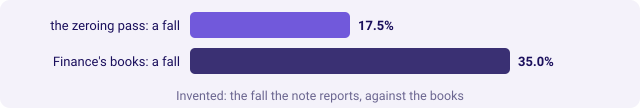

In [4]:
z_change = change(sum(zeroed["Q1"]), sum(zeroed["Q2"]))
gap = {q: ctl(q)[0] - sum(zeroed[q]) for q in QUARTERS}
kit.table(["quarter", "orders", "Finance's orders", "summed", "Finance's rupees", "gap"],
          [(q, len(zeroed[q]), ctl(q)[1], kit.rupees(sum(zeroed[q])), kit.rupees(ctl(q)[0]), kit.rupees(gap[q]))
           for q in QUARTERS], caption="Invented: counts land, rupees do not")
kit.bars([("the zeroing pass: a fall", round(abs(z_change), 1)), ("Finance's books: a fall", round(abs(truth), 1))],
         fmt=lambda v: f"{v:.1f}%", lit=(1,), width=640, title="Invented: the fall the note reports, against the books")
kit.check("every order count lands on Finance's", all(len(zeroed[q]) == ctl(q)[1] for q in QUARTERS))
kit.check("the rupees miss Finance's in one quarter and land in the other",
          sum(1 for q in QUARTERS if gap[q] != 0) == 1 and all(gap[q] >= 0 for q in QUARTERS))

**What happened.** The answer is c. The counts reconcile, Q1's rupees come up Rs 8,50,000 short,
about a fifth of the quarter, and the note reports a fall of 17.5 percent where the books show
35.0.

**Why it is wrong.** The `try` turned "I could not read this value" into "this order was worth
nothing", and zero is a number, so no later step can tell the difference. A count check cannot see
it, because the row is still there. The direction is right, so nobody argues, and the size is half,
so nobody acts at the right scale. The check that catches it is the one chapter 1 made standard:
the rupees against the control total.

**Your turn, on this morning's file.** Which quarter misses, and by how much? Type these lines into
the empty cell below and run it:

```python
lab_gap = {q: ctl(q, lab_book)[0] - sum(lab_zeroed[q]) for q in QUARTERS}
kit.table(["quarter", "orders", "Finance's orders", "summed", "Finance's rupees", "gap"],
          [(q, len(lab_zeroed[q]), ctl(q, lab_book)[1], kit.rupees(sum(lab_zeroed[q])),
            kit.rupees(ctl(q, lab_book)[0]), kit.rupees(lab_gap[q])) for q in QUARTERS],
          caption="This morning's file: counts against rupees")
```

## 3. Which of four answers fits a value that will not convert?

A value that will not convert is a decision, and it goes in the log whichever way it goes. The
cell below sizes four answers on the invented export, on what separates them: what each assumes
about the value, the analyst's minutes, what the log and the reconciliation then show, and the
headline each lets through. The minutes are this programme's estimate, and D's is a wait on
another team.

| Option | What it does |
|---|---|
| A. Zero in a try | Sets the value to 0 and says nothing |
| B. Drop with a reason | Rejects the row and logs why |
| C. Read it, convert, keep and flag | Reads the value without guessing, and logs the text and the number |
| D. Hold and ask the owner | Leaves the row out of today's totals until the order's owner confirms the amount, and the note says it is provisional |

option,assumes,analyst minutes,log lines,count check,rupee check,headline sent
A,the order was worth nothing,1,0,passes,fails,-17.5%
B,the row is not an order,2,1,fails,fails,-17.5%
C,the value can be read without a guess,3,1,passes,passes,-35.0%
D,only the order's owner can say,a wait,1,fails,fails,provisional


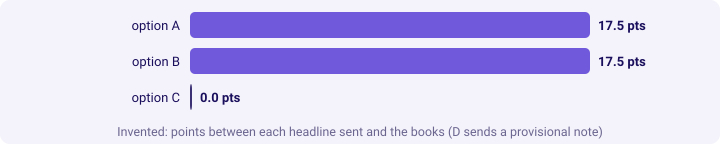

In [5]:
def run_option(src, option):
    """Each quarter's rupees and orders, and the log, under one answer to a value that will not convert."""
    kept, counts, log = {q: 0 for q in QUARTERS}, {q: 0 for q in QUARTERS}, []
    for r in src:
        v = r["amount"]
        if v.isdigit():
            kept[r["quarter"]] += int(v)
            counts[r["quarter"]] += 1
            continue
        if option == "A":
            counts[r["quarter"]] += 1
        elif option == "B":
            log.append("drop: value will not convert")
        elif option == "C":
            kept[r["quarter"]] += read_value(v)
            counts[r["quarter"]] += 1
            log.append("convert and flag: read without a guess")
        else:
            log.append("held: asked the order's owner")
    return kept, counts, log


def size_answers(src, book):
    table_rows, points = [], []
    books = change(ctl("Q1", book)[0], ctl("Q2", book)[0])
    for option, assumes, minutes in [("A", "the order was worth nothing", 1), ("B", "the row is not an order", 2),
                                     ("C", "the value can be read without a guess", 3),
                                     ("D", "only the order's owner can say", "a wait")]:
        kept, counts, log = run_option(src, option)
        sent = change(kept["Q1"], kept["Q2"])
        count_ok = all(counts[q] == ctl(q, book)[1] for q in QUARTERS)
        rupee_ok = all(kept[q] == ctl(q, book)[0] for q in QUARTERS)
        table_rows.append((option, assumes, minutes, len(log), "passes" if count_ok else "fails",
                           "passes" if rupee_ok else "fails", "provisional" if option == "D" else f"{sent:+.1f}%"))
        if option != "D":
            points.append((f"option {option}", round(abs(sent - books), 1)))
    return table_rows, points


ANSWER_HEADERS = ["option", "assumes", "analyst minutes", "log lines", "count check", "rupee check", "headline sent"]
opt_rows, pts = size_answers(once, control)
kit.table(ANSWER_HEADERS, opt_rows, caption="Invented: four answers to a value that will not convert, sized")
kit.bars(pts, lit=(2,), fmt=lambda v: f"{v:.1f} pts",
         title="Invented: points between each headline sent and the books (D sends a provisional note)")

In [6]:
kit.check("only A leaves no trace in the log", [r[3] for r in opt_rows] == [0, 1, 1, 1])
kit.check("B fails the count check, so its gap is visible", opt_rows[1][4] == "fails")
kit.check("C passes both checks", opt_rows[2][4] == opt_rows[2][5] == "passes")

**What happened, and the best-fit call.** C, when the value can be read without a guess: reading it
costs a minute and one log line and lands both quarters on the books. A is the only option that is
never right: it sends the same -17.5 percent as B and hides it. B is honest and still wrong by 17.5
points; what it has going for it is that the count check now fails, so its gap is visible. D is
right on the day the text could be read two ways.

**What would change the call.** Text that cannot be read without a guess moves the call to D: a
value written as a word, a decimal whose unit is unclear (lakh or crore), a currency that is not
the file's. A row that is not an order at all, a test transaction, moves it to B. Whichever way it
goes, the decision lives in a log line and shows in the reconciliation.

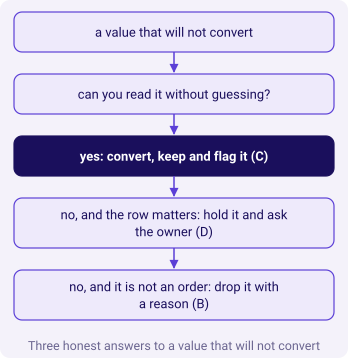

In [7]:
kit.vflow(["a value that will not convert",
           "can you read it without guessing?",
           "yes: convert, keep and flag it (C)",
           "no, and the row matters: hold it and ask the owner (D)",
           "no, and it is not an order: drop it with a reason (B)"], lit=2,
          title="Three honest answers to a value that will not convert")

**Your turn, on this morning's file.** Size the same four answers on the lab export, then find the
row the rupee check points at and read its value yourself. Type these lines into the empty cell
below and run it:

```python
kit.table(ANSWER_HEADERS, size_answers(lab_once, lab_book)[0], caption="The four answers on this morning's file")
for r in lab_once:
    if not r["amount"].isdigit():
        print(r)
```

Can this value be read without a guess, and so which option does it call for? Write the
decisions-log line you would hand Anand's analyst: the order id, the decision and the reason, in one
row.

## 4. What does reading the value change in the note?

**Predict before you run.** Reading the value moves the invented headline from -17.5 to -35.0
percent. How many more rupees of fall does Monday's review now have to explain?

- a) Rs 5,50,000.
- b) Rs 8,50,000.
- c) Rs 14,00,000.
- d) Rs 26,00,000.

In [8]:
fixed, fixed_counts, fixed_log = run_option(once, "C")
kit.table(["the decision about the value", "Q1", "Q1 to Q2"],
          [("zero in a try", kit.rupees(sum(zeroed["Q1"])), f"{change(sum(zeroed['Q1']), sum(zeroed['Q2'])):+.1f}%"),
           ("read, convert, flag", kit.rupees(fixed["Q1"]), f"{change(fixed['Q1'], fixed['Q2']):+.1f}%")],
          caption="Invented: the same rows, two decisions about one value")
kit.check("the fixed pass lands on both control totals", all(fixed[q] == ctl(q)[0] for q in QUARTERS))
kit.check("one log line records the decision", len(fixed_log) == 1)

the decision about the value,Q1,Q1 to Q2
zero in a try,"Rs 31,50,000",-17.5%
"read, convert, flag","Rs 40,00,000",-35.0%


**What happened.** The answer is b. One log line adds Rs 8,50,000 of fall to the note: the
invented export's reported fall grows from Rs 5,50,000, 17.5 percent, to Rs 14,00,000, 35.0 percent,
on the books. In the review, that is the difference between "a soft quarter" and "a quarter to
explain".

## 5. Can a segment filter drop a row without a word, as the zero did?

A pass looks clean whenever a step can lose something without saying so. The next place it happens
is the tree: a filter on the segment name never sees a row whose segment is empty. On the invented
export one Q1 order has no segment, and its customer's other orders are all Retail-Core.

**Predict before you run.** Read on named rows only, what does Retail-Core's change from Q1 to Q2
look like?

- a) A fall of 1.0 percent.
- b) A rise of 2.2 percent.
- c) No change at all.
- d) A fall of about 3 percent.

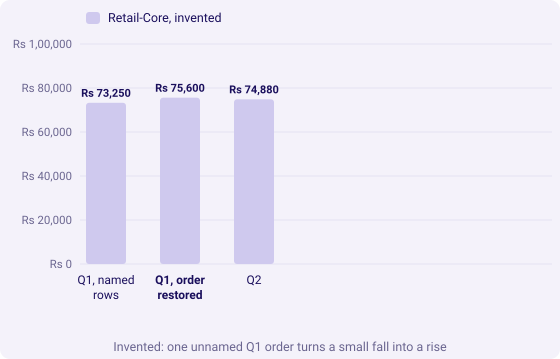

In [9]:
def named_and_restored(src, seg):
    """A segment's quarters on named rows, and with each unnamed row restored from its customer's other orders."""
    named = {q: sum(read_value(r["amount"]) for r in src if r["quarter"] == q and r["segment"] == seg) for q in QUARTERS}
    restored = dict(named)
    for r in src:
        if r["segment"]:
            continue
        others = {o["segment"] for o in src if o["customer_id"] == r["customer_id"] and o["segment"]}
        if others == {seg}:
            restored[r["quarter"]] += read_value(r["amount"])
    return named, restored


named, restored = named_and_restored(once, "Retail-Core")
blank = [r for r in once if not r["segment"]]
kit.columns(["Q1, named rows", "Q1, order restored", "Q2"],
            [("Retail-Core, invented", [named["Q1"], restored["Q1"], named["Q2"]])],
            fmt=lambda v: kit.rupees(v), lit=(1,), width=560,
            title="Invented: one unnamed Q1 order turns a small fall into a rise")
kit.check("the named segments fall one order short of the quarter",
          sum(1 for r in once if r["quarter"] == "Q1" and r["segment"] in SEGS) == ctl("Q1")[1] - len(blank))
kit.check("named rows read a rise where the restored segment fell",
          change(named["Q1"], named["Q2"]) > 0 > change(restored["Q1"], restored["Q2"]),
          f"{change(named['Q1'], named['Q2']):+.1f}% against {change(restored['Q1'], restored['Q2']):+.1f}%")

**What happened.** The answer is b. On named rows the invented Retail-Core's Q1 is Rs 73,250, so the
segment seems to rise 2.2 percent to Q2's Rs 74,880; with the order restored from its customer's
other orders Q1 is Rs 75,600 and the segment fell 1.0 percent, so the named rows turned a fall into
a rise.

**Why it is wrong, and the fix.** The filter dropped the order, and nobody chose to drop it. The
check is one line, that the segments add back to the quarter in orders and in rupees, and it fails by exactly
the rows the filter never saw. The fix is a logged decision: restore the segment from the customer's
other orders when all of them carry one segment, flag it and name it in the caveat, or keep the row
as "segment unknown", named and flagged, with the segment sums reconciled to the quarter.

**Your turn, on this morning's file.** Do the lab file's named segments add back to each quarter,
and if a quarter falls short, which segment moves when the row is restored? Type these lines into
the empty cell below and run it:

```python
for q in QUARTERS:
    n = sum(1 for r in lab_once if r["quarter"] == q and r["segment"] in SEGS)
    print(q, "named orders", n, "against Finance's", ctl(q, lab_book)[1])
for r in lab_once:
    if not r["segment"]:
        others = {o["segment"] for o in lab_once if o["customer_id"] == r["customer_id"] and o["segment"]}
        print(r["order_id"], r["quarter"], "customer's other segments:", others)
        if len(others) == 1:
            seg = next(iter(others))
            n_, r_ = named_and_restored(lab_once, seg)
            print(f"{seg}: {change(n_['Q1'], n_['Q2']):+.1f}% on named rows, "
                  f"{change(r_['Q1'], r_['Q2']):+.1f}% with the order restored")
```

## 6. Can the file alone, with no control total, find the gap?

The rupee check found the gap from outside the file. The second route finds it from inside, and it
should land on the same number: every value present is either summed as it came or appears in the
log with the number it was read as. Values present equal values that convert plus values logged,
and the logged values add up to the gap. The rupee check uses Finance's total and this uses only the
file, so each can fail where the other passes.

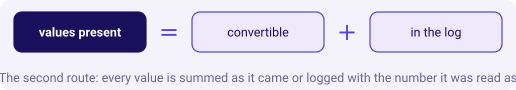

In [10]:
def value_accounting(src):
    present = sum(1 for r in src if r["amount"] != "")
    convertible = sum(1 for r in src if r["amount"].isdigit())
    logged = [read_value(r["amount"]) for r in src if not r["amount"].isdigit()]
    return present, convertible, logged


present, convertible, logged = value_accounting(once)
rupee_gap = sum(gap.values())
kit.equation(["values present", "=", "convertible", "+", "in the log"],
             title="The second route: every value is summed as it came or logged with the number it was read as")
kit.check("present equals convertible plus logged", present == convertible + len(logged),
          f"{present} = {convertible} + {len(logged)}")
kit.check("the logged values add up to the gap the rupee check found", sum(logged) == rupee_gap, kit.rupees(rupee_gap))

**What happened.** On the invented export 167 values are present, 166 convert and 1 is logged, and
the logged value, Rs 8,50,000, is exactly the gap the rupee check found.

**When to switch routes.** The rupee check needs a control total and tells you how much is missing;
the value accounting needs nothing outside the file and tells you where. On a file with no control
total, the value accounting is the check you still have.

**Your turn, on this morning's file.** Type this line into the empty cell below and run it:

```python
lab_present, lab_convertible, lab_logged = value_accounting(lab_once)
print(lab_present, "=", lab_convertible, "+", len(lab_logged), "| logged", [kit.rupees(v) for v in lab_logged],
      "| the gap", kit.rupees(sum(lab_gap.values())))
```

> **Kavya's review.** A count check proves the rows are there. Only a rupee check proves the values
> survived. Setting a value to zero claims the order was worth nothing, so that decision belongs in
> the log with a reason.

### How would you answer this in an interview?

**[D] Your cleaning pass reports zero rejects. What do you check?** "I distrust the zero before I
trust it. First, rows against distinct ids, because a repeated batch is the commonest reason a total
runs high. Second, how my code handled a value that would not convert: if a `try` set it to zero,
the rejects count is hiding it. Third, the rupees per period against a control total, with a bridge
from my number to theirs. On a training export a zeroing pass reconciled every count and still left
the base quarter Rs 8,50,000 short, which halved the fall the note reported."

**[F] How do you handle a value that will not convert?** "Three honest answers: read it and convert
it when it can be read without guessing, hold it and ask the owner when it cannot, drop it with a
reason when the row is not an order. Every one gets a log line and shows in the reconciliation. I
never set it to zero, because zero is a number and nothing later can tell it from a real one."

**The design question: when would you drop the row instead of reading it?** "When the row is not
the thing being counted, a test order or a cancelled draft, and the log says so. When the value
matters and I cannot read it without guessing, I hold it and ask, and the note says the quarter is
provisional by that amount."

### Where else can a pass look clean?

A pass can look clean at any step that loses something silently: a date parse that sends a bad date to a default, a
currency converter that returns zero for a code it does not know, a filter on a name that is
sometimes blank. The check is always the same: what went in equals what came out plus what was
set aside, in rows and in value.

## So, when every count reconciles, is the pass finished?

It is finished only once the rupees land too. On the invented export:

1. The zeroing pass reports 83 Q1 orders against Finance's 83, and 0 rejects.
2. The rupees show Q1 Rs 8,50,000 short, and the note's fall reads 17.5 percent where the books say
   35.0.
3. Reading the value, keeping it and flagging it (C) is the best fit when it can be read without a
   guess; D fits when it cannot, B when the row is not an order, and A never does.
4. One log line moves the fall to 35.0 percent, Rs 14,00,000 on the books.
5. A segment filter drops the unnamed order, and Retail-Core reads +2.2 percent where it fell 1.0.
6. Values present, 167, equal 166 that convert plus 1 logged, and the logged Rs 8,50,000 is the gap.

Chapter 3 takes the reconciled numbers into the tree and asks which of the right numbers leads.

In [11]:
kit.check_summary()
print("Next, chapter 3: which finding leads the note, and how sure can Meera be of it?")

Next, chapter 3: which finding leads the note, and how sure can Meera be of it?
